#### Trích xuất đặc trưng ảnh và biểu diễn dưới dạng numpy.array() từ mô hình ResNet
> **ResNet** là gì? Kiến trúc CNN   
> ResNet nhận input là tensor của ảnh size 224x224 


In [2]:
import numpy 
import timm
import torch
from torchvision import models
from torchvision import transforms 
from PIL import Image

image = Image.open('img/cat01.png').convert("RGB")
process = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
tensor_img = process(image)

resnet50_model = timm.create_model("resnet50", pretrained=True, num_classes=0)
resnet50_model.eval()

with torch.no_grad():
    feature = resnet50_model(tensor_img.unsqueeze(0))

feature = numpy.array(feature)
feature


/tmp/ipykernel_26189/1653874222.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  feature = numpy.array(feature)


array([[0.00571434, 0.00405172, 0.00416761, ..., 0.        , 0.06344695,
        0.        ]], shape=(1, 2048), dtype=float32)

In [ ]:
import os
images = [Image.open(os.path.join('img', img_file)).convert('RGB') for img_file in os.listdir('img') ]
dataset_preprocess = [ process(image) for image in images]
with torch.no_grad(): dataset_feature    =  numpy.squeeze(numpy.array([ numpy.array( resnet50_model (data_preprocess.unsqueeze (0) ) ) for data_preprocess in dataset_preprocess ]), axis=1)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
out_cluster = kmeans.fit_predict(dataset_feature)
out_cluster

/tmp/ipykernel_26189/1203437054.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  with torch.no_grad(): dataset_feature    =  numpy.squeeze(numpy.array([ numpy.array( resnet50_model (data_preprocess.unsqueeze (0) ) ) for data_preprocess in dataset_preprocess ]), axis=1)


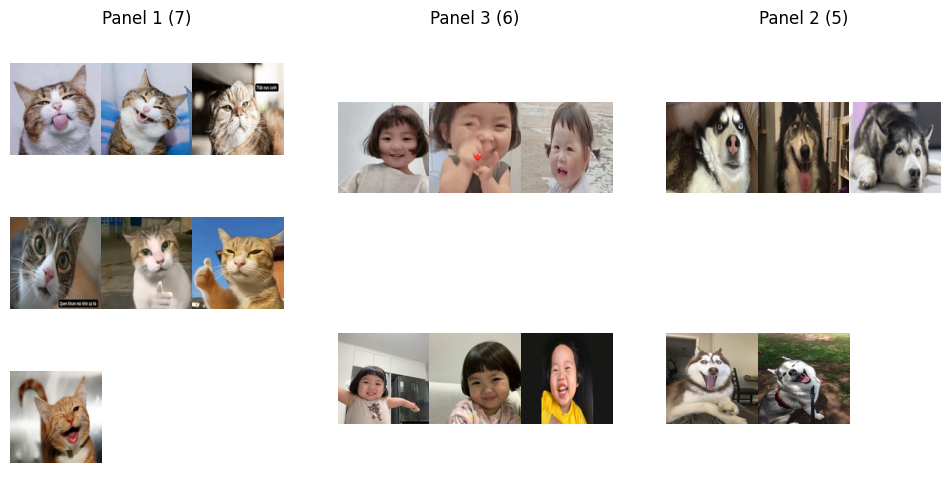

In [6]:
import matplotlib.pyplot as plt
import math

def show_two_panels_matplotlib(images, left_indices, mid_indices, thumb_size=(128,128), cols=3):
    left_imgs = [images[i].copy().resize(thumb_size, Image.LANCZOS) for i in left_indices]
    mid_imgs  = [images[i].copy().resize(thumb_size, Image.LANCZOS) for i in mid_indices]
    right_imgs = [images[i].copy().resize(thumb_size, Image.LANCZOS) for i in range(len(images)) if i not in left_indices and i not in mid_indices]

    def plot_grid(ax, imgs, cols):
        ax.axis('off')
        if len(imgs) == 0:
            ax.text(0.5, 0.5, "Empty", ha='center', va='center')
            return
        rows = math.ceil(len(imgs)/cols)
        for idx, img in enumerate(imgs):
            r = idx // cols
            c = idx % cols
            ax_inset = ax.inset_axes([c/cols, 1-(r+1)/rows, 1/cols, 1/rows])  # đơn giản chia vị trí
            ax_inset.imshow(img)
            ax_inset.axis('off')

    fig, (axL, axR, axM) = plt.subplots(1,3, figsize=(12,6))
    axL.set_title(f"Panel 1 ({len(left_imgs)})")
    axM.set_title(f"Panel 2 ({len(mid_imgs)})")
    axR.set_title(f"Panel 3 ({len(right_imgs)})")
    plot_grid(axL, left_imgs, cols)
    plot_grid(axM, mid_imgs, cols)
    plot_grid(axR, right_imgs, cols)
    plt.show()

left_images = [] 
mid_images = [] 
for i in range(len (images)) :
    if out_cluster[i] == 1:
        left_images.append(i)
    elif out_cluster[i] == 2:
        mid_images.append(i)

show_two_panels_matplotlib(images, left_images, mid_images)

